# Memorization vs Learning in Fluoroquinolone Resistance Prediction

Analysis showing how non-singleton approaches achieve misleading performance through memorization rather than biological understanding.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn import metrics 
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib.gridspec import GridSpec

import seaborn as sns
from xgboost import XGBClassifier

Check resistance mutation distribution

In [5]:
# Make a table of the most common resistance mutations in each dataset, with one column for LEV and one for MXF
lev_data = pd.read_csv('data/ML_DATA_LEV.csv')
lev_mutations = lev_data.GENE_MUTATION.value_counts().reset_index()
lev_mutations.columns = ['GENE_MUTATION', 'LEV_count']
mxf_mutations = pd.read_csv('data/ML_DATA_MXF.csv')
mxf_mutations = mxf_mutations.GENE_MUTATION.value_counts().reset_index()
mxf_mutations.columns = ['GENE_MUTATION', 'MXF_count']
common_mutations = pd.merge(lev_mutations, mxf_mutations, how='outer', on='GENE_MUTATION').fillna(0)
common_mutations['LEV_count'] = common_mutations['LEV_count'].astype(int)
common_mutations['MXF_count'] = common_mutations['MXF_count'].astype(int)
common_mutations['total %'] = round((common_mutations['LEV_count'] + common_mutations['MXF_count']) / (sum(lev_mutations['LEV_count']) + sum(mxf_mutations['MXF_count'])) * 100, 2)
common_mutations.sort_values(by='LEV_count', ascending=False, inplace=True)
common_mutations.rename(columns={'GENE_MUTATION':'Mutation','LEV_count': 'Levofloxacin', 'MXF_count': 'Moxifloxacin'}, inplace=True)
common_mutations[:15].to_latex(index=False)

'\\begin{tabular}{lrrr}\n\\toprule\nMutation & Levofloxacin & Moxifloxacin & total % \\\\\n\\midrule\ngyrA_D94G & 632 & 621 & 36.120000 \\\\\ngyrA_A90V & 340 & 338 & 19.540000 \\\\\ngyrA_D94N & 137 & 138 & 7.930000 \\\\\ngyrA_D94A & 85 & 88 & 4.990000 \\\\\ngyrA_S91P & 63 & 67 & 3.750000 \\\\\ngyrA_D94Y & 60 & 62 & 3.520000 \\\\\ngyrA_D94H & 38 & 35 & 2.100000 \\\\\ngyrA_N193S & 27 & 20 & 1.350000 \\\\\ngyrA_P472S & 23 & 14 & 1.070000 \\\\\ngyrA_G88C & 22 & 24 & 1.330000 \\\\\ngyrB_E501D & 18 & 17 & 1.010000 \\\\\ngyrA_T267I & 12 & 12 & 0.690000 \\\\\ngyrB_D461N & 10 & 13 & 0.660000 \\\\\ngyrA_P154R & 9 & 9 & 0.520000 \\\\\ngyrB_R446C & 9 & 10 & 0.550000 \\\\\n\\bottomrule\n\\end{tabular}\n'

## Part 1: Non-singleton approach with duplicate samples

In [2]:
# Load data with all duplicate mutations
data = pd.read_csv('data/ML_DATA_MXF.csv')
data = pd.read_csv('data/ML_DATA_LEV.csv')
data.dropna(inplace=True)

print("Total samples with duplicates:", len(data))
print("Unique mutations:", data.GENE_MUTATION.nunique())
print("Average samples per mutation:", len(data)/data.GENE_MUTATION.nunique())

data.CLEAN_BINARY_PHENOTYPE.value_counts()

Total samples with duplicates: 1701
Unique mutations: 163
Average samples per mutation: 10.43558282208589


CLEAN_BINARY_PHENOTYPE
R    1393
S     308
Name: count, dtype: int64

In [3]:
# Prepare features and labels
features = ['d_volume', 'd_hydropathy_KD', 'd_hydropathy_WW',
       'd_MW', 'd_Pi', 'secondary_structure', 'phi', 'psi', 'residue_sasa', 
       'n_hbond_acceptors', 'n_hbond_donors', 'SASA', 'snap2_score', 'dist_MGB', 'dist_MGE', 'dist_drug', 'temp_factor', 'depth', 'deep_ddG'] # 'B', 'C', 'E', 'G', 'H', 'T',

features_LEV = [
       'd_MW', 'd_Pi', 'secondary_structure', 'phi', 
       'snap2_score', 'dist_MGB', 'dist_MGE', 'dist_drug', 'temp_factor', 'depth', 'deep_ddG']

features_MXF = ['d_volume',
       'd_MW', 'd_Pi', 'secondary_structure', 'psi',
       'n_hbond_acceptors', 'snap2_score', 'dist_MGB', 'dist_MGE', 'dist_drug', 'temp_factor']


true_label = data.CLEAN_BINARY_PHENOTYPE
features = data[features_MXF].copy()
features = data[features_LEV].copy()
features['secondary_structure_codes'] = pd.Categorical(features.secondary_structure, 
                                                      categories=features.secondary_structure.unique()).codes
features.drop('secondary_structure', inplace=True, axis=1)

replacement = {"R": 1, "S": 0}
y = true_label.replace(replacement)

random_seed = 144
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.30, random_state=random_seed)

In [4]:
# model selection with cross-validation
random_seed = 144

folds = StratifiedKFold(n_splits = 5, random_state = random_seed, shuffle = True)

param_grid = [ 
                {   'penalty': ['l2'],
                    'solver'  : ['newton-cg', 'lbfgs', 'liblinear', 'newton-cholesky', 'sag', 'saga'], 
                    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                    'class_weight' : ['balanced', None]
                } 
            ]

gsvc_lr = GridSearchCV(LogisticRegression(random_state=random_seed), 
                    param_grid, 
                    cv = folds, 
                    scoring = ['recall', 'roc_auc', 'precision'], 
                    refit = 'recall') #, scoring='f1' , scoring = 'recall'
gsvc_lr.fit(X_train,y_train)

gsvc_lr.best_params_

/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refe

{'C': 0.001, 'class_weight': None, 'penalty': 'l2', 'solver': 'newton-cg'}

In [6]:
folds = StratifiedKFold(n_splits = 5, random_state = random_seed, shuffle = True)

model_xgb = XGBClassifier()

param_grid = [ 
        {   'n_estimators': [25, 50, 100, 150, 200],
            'subsample': [0.6, 0.7, 0.8, 0.9, 1],
            'max_depth':[2,4,5,6,8],
            'min_child_weight': [0, 0.1, 1, 10],
            'learning_rate':[0.005, 0.01, 0.05, 0.075, 0.1, 0.125, 0.1] } 
    ]

gsvc_xgb = GridSearchCV(model_xgb, 
                    param_grid, 
                    cv = folds, 
                    n_jobs=-1,
                    return_train_score=True,
                    scoring = ['recall', 'roc_auc', 'precision'], 
                    refit = 'recall') #, scoring='f1' , scoring = 'recall'

gsvc_xgb.fit(X_train,y_train)
gsvc_xgb.best_estimator_

KeyboardInterrupt: 

In [ ]:
gsvc_xgb.best_estimator_.subsample

0.6

In [41]:
# Train models on non-singleton data
logreg = LogisticRegression(solver='newton-cg', random_state=random_seed, 
                           class_weight=None, C=1, penalty='l2')
logreg = LogisticRegression(solver='newton-cg', random_state=random_seed,
                           class_weight=None, C=0.001, penalty='l2')
logreg.fit(X_train, y_train)

xgb = XGBClassifier(n_estimators=150, subsample=1, max_depth=4, 
                   min_child_weight=0, learning_rate=0.01, random_state=random_seed)
xgb = XGBClassifier(n_estimators=150, subsample=0.6, max_depth=2, 
                   min_child_weight=0, learning_rate=0.1, random_state=random_seed)
xgb.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

print("Logistic Regression accuracy:", metrics.accuracy_score(y_test, y_pred_lr))
print("XGBoost accuracy:", metrics.accuracy_score(y_test, y_pred_xgb))

# Calculate sensitivity and specificity for non-singleton approach
cnf_matrix_lr = metrics.confusion_matrix(y_test, y_pred_lr)
cnf_matrix_xgb = metrics.confusion_matrix(y_test, y_pred_xgb)

if cnf_matrix_lr.shape == (2, 2):
    tn, fp, fn, tp = cnf_matrix_lr.ravel()
    sensitivity_lr = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_lr = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"LR Sensitivity (resistance detection): {sensitivity_lr:.3f}")
    print(f"LR Specificity (susceptible detection): {specificity_lr:.3f}")

if cnf_matrix_xgb.shape == (2, 2):
    tn, fp, fn, tp = cnf_matrix_xgb.ravel()
    sensitivity_xgb = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_xgb = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"XGB Sensitivity (resistance detection): {sensitivity_xgb:.3f}")
    print(f"XGB Specificity (susceptible detection): {specificity_xgb:.3f}")

Logistic Regression accuracy: 0.9726027397260274
XGBoost accuracy: 0.9941291585127201
LR Sensitivity (resistance detection): 0.998
LR Specificity (susceptible detection): 0.854
XGB Sensitivity (resistance detection): 1.000
XGB Specificity (susceptible detection): 0.966


/var/folders/_3/8y_dwngx2614_y_52fzh1c4w0000gn/T/ipykernel_84835/2280756186.py:52: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)


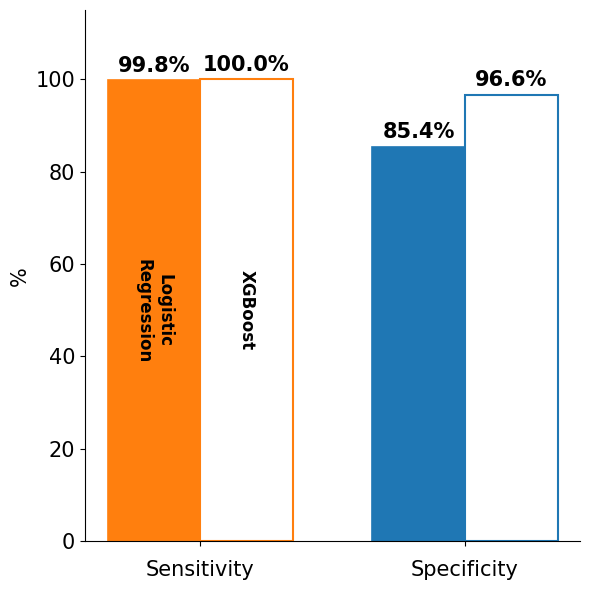

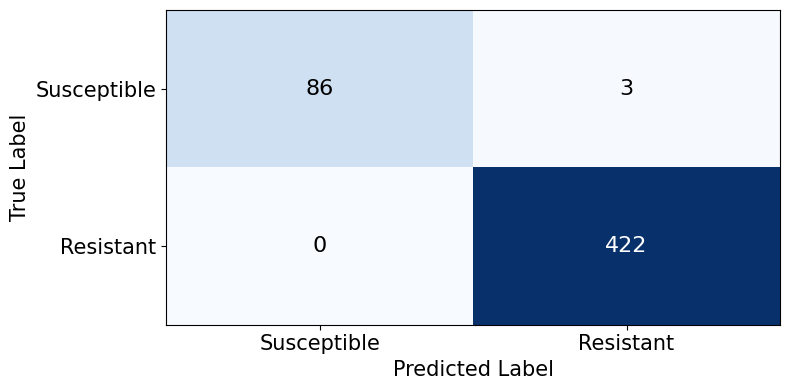

In [42]:
# Plot sensitivity and specificity with enhanced styling (matching reference plot style)
x_pos = np.arange(2)  # 0 = Sensitivity, 1 = Specificity
bar_width = 0.35

fig, ax = plt.subplots(figsize=(6, 6))

# Colors matching your original plot but with the professional styling
blue = '#1f77b4'    # Sensitivity (tab:blue equivalent)
orange = '#ff7f0e'  # Specificity (tab:orange equivalent)

# Bar values for both models
lr_values = [sensitivity_lr, specificity_lr]  # Logistic Regression
xgb_values = [sensitivity_xgb, specificity_xgb]  # XGBoost

# Create bars with filled and hollow styling
bars_lr = ax.bar(x_pos - bar_width/2, lr_values, width=bar_width,
                 color=[orange, blue], edgecolor=[orange, blue], linewidth=1.2)

bars_xgb = ax.bar(x_pos + bar_width/2, xgb_values, width=bar_width,
                  color='white', edgecolor=[orange, blue], linewidth=1.5)

# Add percentage labels above bars
for bar, val in zip(list(bars_lr) + list(bars_xgb), lr_values + xgb_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val * 100:.1f}%', ha='center', va='bottom', fontsize=15, fontweight='bold')

# Add model labels inside bars (rotated)
model_labels_lr = ['Logistic\nRegression', '']
model_labels_xgb = ['XGBoost', '']

for i in range(2):  # 0 = sensitivity, 1 = specificity
    if model_labels_lr[i]:
        bar = bars_lr[i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                model_labels_lr[i], ha='center', va='center', rotation=270,
                fontsize=12, color='black', fontweight='bold')
    if model_labels_xgb[i]:
        bar = bars_xgb[i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                model_labels_xgb[i], ha='center', va='center', rotation=270,
                fontsize=12, color='black', fontweight='bold')

# Set labels and styling
ax.set_xticks(x_pos)
ax.set_xticklabels(['Sensitivity', 'Specificity'], fontsize=15)
ax.xaxis.set_tick_params(pad=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('%', fontsize=15)

# Format y-axis as percentages
yticks = ax.get_yticks()
ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)

# Clean styling - remove top and right spines
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', labelsize=15)

plt.tight_layout()
# plt.savefig('pdf/overall_performance_sen_spec.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.show()

# Keep the confusion matrix visualization
fig, ax2 = plt.subplots(figsize=(8, 4))
cm = cnf_matrix_xgb
im = ax2.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, aspect='auto')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax2.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=16)

ax2.set_ylabel('True Label', fontsize=15)
ax2.set_xlabel('Predicted Label', fontsize=15)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Susceptible', 'Resistant'], fontsize=15)
ax2.set_yticklabels(['Susceptible', 'Resistant'], fontsize=15)

# Force the aspect ratio to be rectangular (2:1)
ax2.set_aspect('auto')

plt.tight_layout()
# plt.savefig('pdf/XGBoost_confusion_matrix.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.show()

In [45]:
# check out the misclassified resistant samples in XGBoost
misclassified_indices = X_test[((y_test == 1) & (y_pred_xgb == 0))|((y_test == 0) & (y_pred_xgb == 1))].index
misclassified_samples = data.loc[misclassified_indices]
print("Misclassified resistant samples:\n", misclassified_samples)

Misclassified resistant samples:
      index DRUG   MIC  LOG2MIC BINARY_PHENOTYPE PHENOTYPE_QUALITY  GENE  \
227    227  LEV   1.0      0.0                S              HIGH  gyrA   
14      14  LEV   1.0      0.0                S            MEDIUM  gyrB   
443    443  LEV  0.25     -2.0                S              HIGH  gyrB   

     POSITION GENE_MUTATION CLEAN_BINARY_PHENOTYPE  ...      T       SASA  \
227      79.0     gyrA_E79K                      S  ...  False  40.660144   
14      499.0    gyrB_N499I                      S  ...  False  40.444768   
443     499.0    gyrB_N499S                      S  ...  False  40.444768   

    snap2_score  snap2_accuracy   dist_MGB   dist_MGE  dist_drug  temp_factor  \
227        58.0            75.0  18.499075  18.758667  22.783238    52.490002   
14         48.0            71.0  21.565351  18.549803  13.333886    62.860001   
443       -33.0            66.0  21.565351  18.549803  13.333886    62.860001   

        depth deep_ddG  
227  2

In [1]:
# check if these misclassified samples have mutations that were not in the training set
train_mutations = set(data.loc[X_train.index, 'GENE_MUTATION'])
test_mutations = set(data.loc[X_test.index, 'GENE_MUTATION'])
misclassified_mutations = set(misclassified_samples['GENE_MUTATION'])
unseen_mutations = misclassified_mutations - train_mutations
print("Unseen mutations in misclassified samples:", unseen_mutations)
print("Out of", len(misclassified_mutations), "misclassified samples,",len(unseen_mutations),"have mutations that are not present in the training set.")

NameError: name 'data' is not defined

## Part 2: Data leakage analysis

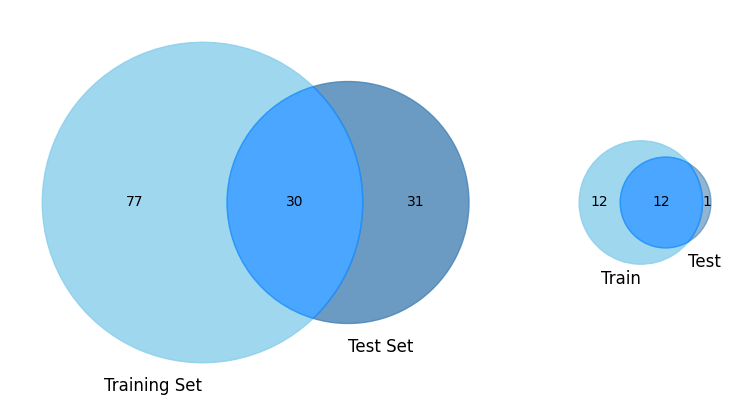

In [ ]:
# Prepare data
train_data = data.loc[X_train.index]
test_data = data.loc[X_test.index]

train_susceptible = set(train_data[train_data.CLEAN_BINARY_PHENOTYPE == 'S']['GENE_MUTATION'])
test_susceptible = set(test_data[test_data.CLEAN_BINARY_PHENOTYPE == 'S']['GENE_MUTATION'])

train_resistant = set(train_data[train_data.CLEAN_BINARY_PHENOTYPE == 'R']['GENE_MUTATION'])
test_resistant = set(test_data[test_data.CLEAN_BINARY_PHENOTYPE == 'R']['GENE_MUTATION'])

# Create figure with tighter grid
fig = plt.figure(figsize=(10, 5))
gs = GridSpec(1, 2, width_ratios=[4, 1])  # 4:1 ratio = second diagram is ~1/4 width of first

# First (larger) Venn diagram – Susceptible
ax1 = fig.add_subplot(gs[0])
venn_s = venn2([train_susceptible, test_susceptible], 
               set_labels=('Training Set', 'Test Set'), ax=ax1)

if venn_s.get_patch_by_id('10'):
    venn_s.get_patch_by_id('10').set_color('#87CEEB')
    venn_s.get_patch_by_id('10').set_alpha(0.8)
if venn_s.get_patch_by_id('01'):
    venn_s.get_patch_by_id('01').set_color('#4682B4')
    venn_s.get_patch_by_id('01').set_alpha(0.8)
if venn_s.get_patch_by_id('11'):
    venn_s.get_patch_by_id('11').set_color('#1E90FF')
    venn_s.get_patch_by_id('11').set_alpha(0.8)

# Second (smaller) Venn diagram – Resistant
ax2 = fig.add_subplot(gs[1])
venn_r = venn2([train_resistant, test_resistant], 
               set_labels=('Train', 'Test'), ax=ax2)

# Color patches
if venn_r.get_patch_by_id('10'):
    venn_r.get_patch_by_id('10').set_color('#87CEEB')
    venn_r.get_patch_by_id('10').set_alpha(0.8)
if venn_r.get_patch_by_id('01'):
    venn_r.get_patch_by_id('01').set_color('#4682B4')
    venn_r.get_patch_by_id('01').set_alpha(0.6)
if venn_r.get_patch_by_id('11'):
    venn_r.get_patch_by_id('11').set_color('#1E90FF')
    venn_r.get_patch_by_id('11').set_alpha(0.8)

# Move "Test" label 
label = venn_r.set_labels[1]  
label.set_x(label.get_position()[0] + 0.2)  # shift right 

# Tighten spacing between subplots
plt.subplots_adjust(wspace=0.01)
# plt.savefig('pdf/mutation_overlap.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.show()

Data split: 476 seen mutations, 35 novel mutations

XGBoost Performance:
Seen mutations   - Sensitivity: 1.000, Specificity: 1.000
Novel mutations  - Sensitivity: 1.000, Specificity: 0.912

Class distribution analysis:
Overall test set:
  - Total samples: 511
  - Resistant: 422 (82.6%)
  - Susceptible: 89 (17.4%)

Seen mutations (training set mutations):
  - Total samples: 476
  - Resistant: 421 (88.4%)
  - Susceptible: 55 (11.6%)

Novel mutations (unseen mutations):
  - Total samples: 35
  - Resistant: 1 (2.9%)
  - Susceptible: 34 (97.1%)

Proportion comparison:
  - Seen mutations resistance rate: 88.4%
  - Novel mutations resistance rate: 2.9%
  - Novel mutations have LOWER resistance rate (-85.6%)


/var/folders/_3/8y_dwngx2614_y_52fzh1c4w0000gn/T/ipykernel_84775/3175108422.py:141: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)


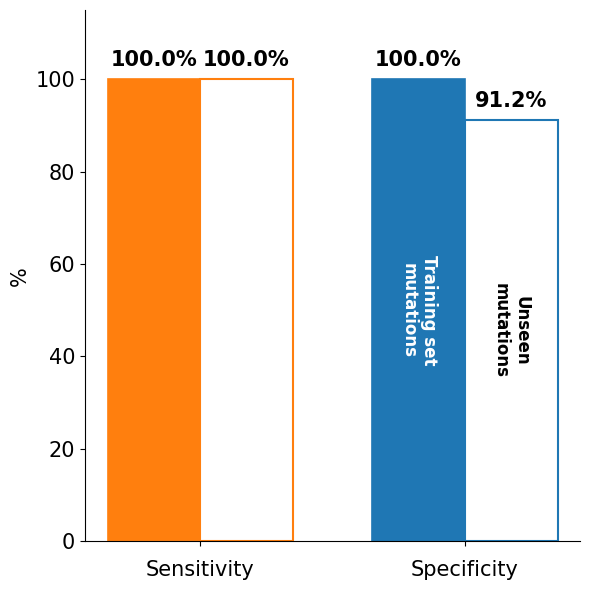


XGBoost Memorization Effect Summary:
Seen mutations (memorization):
  - Sensitivity: 100.0%
  - Specificity: 100.0%
Novel mutations (generalization):
  - Sensitivity: 100.0%
  - Specificity: 91.2%
Performance drops:
  - Sensitivity drop: 0.0%
  - Specificity drop: 8.8%


In [11]:
# Performance on seen vs novel mutations
test_data = data.loc[X_test.index]
overlap_mask = test_data.GENE_MUTATION.isin(overlapping_mutations)
novel_mask = test_data.GENE_MUTATION.isin(novel_mutations)

print(f"Data split: {sum(overlap_mask)} seen mutations, {sum(novel_mask)} novel mutations")

# Calculate sensitivity/specificity for seen and novel mutations (XGBoost only)
if sum(overlap_mask) > 0 and sum(novel_mask) > 0:
    cnf_overlap_xgb = metrics.confusion_matrix(y_test[overlap_mask], y_pred_xgb[overlap_mask])
    cnf_novel_xgb = metrics.confusion_matrix(y_test[novel_mask], y_pred_xgb[novel_mask])
    
    if cnf_overlap_xgb.shape == (2, 2) and cnf_novel_xgb.shape == (2, 2):
        # Seen mutations
        tn, fp, fn, tp = cnf_overlap_xgb.ravel()
        sens_xgb_seen = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec_xgb_seen = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        # Novel mutations  
        tn, fp, fn, tp = cnf_novel_xgb.ravel()
        sens_xgb_novel = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec_xgb_novel = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        print(f"\nXGBoost Performance:")
        print(f"Seen mutations   - Sensitivity: {sens_xgb_seen:.3f}, Specificity: {spec_xgb_seen:.3f}")
        print(f"Novel mutations  - Sensitivity: {sens_xgb_novel:.3f}, Specificity: {spec_xgb_novel:.3f}")
    
    # Analyze class distribution in novel mutations
    print(f"\nClass distribution analysis:")
    print(f"============================")
    
    # Overall test set distribution
    total_resistant = sum(y_test == 1)
    total_susceptible = sum(y_test == 0)
    total_samples = len(y_test)
    
    print(f"Overall test set:")
    print(f"  - Total samples: {total_samples}")
    print(f"  - Resistant: {total_resistant} ({total_resistant/total_samples:.1%})")
    print(f"  - Susceptible: {total_susceptible} ({total_susceptible/total_samples:.1%})")
    
    # Seen mutations distribution
    seen_resistant = sum(y_test[overlap_mask] == 1)
    seen_susceptible = sum(y_test[overlap_mask] == 0) 
    seen_total = sum(overlap_mask)
    
    print(f"\nSeen mutations (training set mutations):")
    print(f"  - Total samples: {seen_total}")
    print(f"  - Resistant: {seen_resistant} ({seen_resistant/seen_total:.1%})")
    print(f"  - Susceptible: {seen_susceptible} ({seen_susceptible/seen_total:.1%})")
    
    # Novel mutations distribution
    novel_resistant = sum(y_test[novel_mask] == 1)
    novel_susceptible = sum(y_test[novel_mask] == 0)
    novel_total = sum(novel_mask)
    
    print(f"\nNovel mutations (unseen mutations):")
    print(f"  - Total samples: {novel_total}")
    print(f"  - Resistant: {novel_resistant} ({novel_resistant/novel_total:.1%})")
    print(f"  - Susceptible: {novel_susceptible} ({novel_susceptible/novel_total:.1%})")
    
    # Compare proportions
    print(f"\nProportion comparison:")
    print(f"  - Seen mutations resistance rate: {seen_resistant/seen_total:.1%}")
    print(f"  - Novel mutations resistance rate: {novel_resistant/novel_total:.1%}")
    
    if novel_resistant/novel_total > seen_resistant/seen_total:
        print(f"  - Novel mutations have HIGHER resistance rate (+{(novel_resistant/novel_total - seen_resistant/seen_total):.1%})")
    else:
        print(f"  - Novel mutations have LOWER resistance rate ({(novel_resistant/novel_total - seen_resistant/seen_total):.1%})")

# Plot XGBoost sensitivity and specificity on seen vs novel mutations (combined)
if len(novel_mutations) > 0:
    # Create single plot combining sensitivity and specificity
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Colors for sensitivity and specificity
    blue = '#1f77b4'    # Sensitivity
    orange = '#ff7f0e'  # Specificity
    
    # Check if we have data for both seen and novel mutations
    if sum(overlap_mask) > 0 and sum(novel_mask) > 0:
        # Get sensitivity and specificity values for XGBoost only
        if cnf_overlap_xgb.shape == (2, 2) and cnf_novel_xgb.shape == (2, 2):
            # Sensitivity for seen mutations
            tn, fp, fn, tp = cnf_overlap_xgb.ravel()
            sens_xgb_seen = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec_xgb_seen = tn / (tn + fp) if (tn + fp) > 0 else 0
            
            # Sensitivity for novel mutations
            tn, fp, fn, tp = cnf_novel_xgb.ravel()
            sens_xgb_novel = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec_xgb_novel = tn / (tn + fp) if (tn + fp) > 0 else 0
            
            # Set up bar positions
            x_pos = np.arange(2)  # 0 = Sensitivity, 1 = Specificity
            bar_width = 0.35
            
            # Values for seen and novel mutations
            seen_values = [sens_xgb_seen, spec_xgb_seen]
            novel_values = [sens_xgb_novel, spec_xgb_novel]
            
            # Create bars - filled for seen (training set), hollow for novel (unseen)
            bars_seen = ax.bar(x_pos - bar_width/2, seen_values, width=bar_width,
                             color=[orange, blue], edgecolor=[orange, blue], linewidth=1.2)
            
            bars_novel = ax.bar(x_pos + bar_width/2, novel_values, width=bar_width,
                              color='white', edgecolor=[orange, blue], linewidth=1.5)
            
            # Add percentage labels above bars
            for bar, val in zip(list(bars_seen) + list(bars_novel), seen_values + novel_values):
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                       f'{val * 100:.1f}%', ha='center', va='bottom', 
                       fontsize=15, fontweight='bold')
            
            # Add mutation type labels inside bars
            mutation_labels_seen = ['', 'Training set\nmutations']
            mutation_labels_novel = ['', 'Unseen\nmutations']
            
            for i in range(2):  # 0 = sensitivity, 1 = specificity
                if mutation_labels_seen[i] and seen_values[i] > 0.15:
                    bar = bars_seen[i]
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                           mutation_labels_seen[i], ha='center', va='center', rotation=270,
                           fontsize=12, color='white', fontweight='bold')
                if mutation_labels_novel[i] and novel_values[i] > 0.15:
                    bar = bars_novel[i]
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                           mutation_labels_novel[i], ha='center', va='center', rotation=270,
                           fontsize=12, color='black', fontweight='bold')
            
            # Set labels and styling
            ax.set_xticks(x_pos)
            ax.set_xticklabels(['Sensitivity', 'Specificity'], fontsize=15)
            ax.xaxis.set_tick_params(pad=10)
            ax.set_ylim(0, 1.15)
            ax.set_ylabel('%', fontsize=15)
            
            # Format y-axis as percentages
            yticks = ax.get_yticks()
            ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)
            
            # Clean styling - remove top and right spines
            ax.spines[['right', 'top']].set_visible(False)
            ax.tick_params(axis='both', labelsize=15)
            
        else:
            ax.text(0.5, 0.5, 'Insufficient data for\ncomparison', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
    else:
        ax.text(0.5, 0.5, 'No novel mutations\nfor comparison', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
    
    plt.tight_layout()
    # plt.savefig('pdf/performance_seen_vs_unseen_mutations.svg', format='svg', dpi=1200, bbox_inches='tight')
    plt.show()
    
    # Print summary of memorization effect (XGBoost only, sensitivity and specificity)
    if sum(overlap_mask) > 0 and sum(novel_mask) > 0 and cnf_overlap_xgb.shape == (2, 2) and cnf_novel_xgb.shape == (2, 2):
        print(f"\nXGBoost Memorization Effect Summary:")
        print(f"===================================")
        print(f"Seen mutations (memorization):")
        print(f"  - Sensitivity: {sens_xgb_seen:.1%}")
        print(f"  - Specificity: {spec_xgb_seen:.1%}")
        print(f"Novel mutations (generalization):")
        print(f"  - Sensitivity: {sens_xgb_novel:.1%}")
        print(f"  - Specificity: {spec_xgb_novel:.1%}")
        print(f"Performance drops:")
        print(f"  - Sensitivity drop: {(sens_xgb_seen - sens_xgb_novel):.1%}")
        print(f"  - Specificity drop: {(spec_xgb_seen - spec_xgb_novel):.1%}")
else:
    print("No novel mutations found for comparison.")

## Part 3: Testing with singleton approach

In [104]:
# Create singleton dataset - one sample per mutation
data_singleton = data.drop_duplicates(subset=['GENE_MUTATION'], keep='first')

print("Singleton samples:", len(data_singleton))
print("Original samples:", len(data))
print("Reduction factor:", len(data) / len(data_singleton))

singleton_counts = data_singleton.CLEAN_BINARY_PHENOTYPE.value_counts()
print("\nSingleton class distribution:")
print(singleton_counts)
print("Resistance rate:", singleton_counts['R'] / len(data_singleton))

Singleton samples: 163
Original samples: 1701
Reduction factor: 10.43558282208589

Singleton class distribution:
CLEAN_BINARY_PHENOTYPE
S    138
R     25
Name: count, dtype: int64
Resistance rate: 0.15337423312883436


In [106]:
# Prepare singleton features
true_label_singleton = data_singleton.CLEAN_BINARY_PHENOTYPE
features_singleton = data_singleton[features_MXF].copy()
features_singleton = data_singleton[features_LEV].copy()
features_singleton['secondary_structure_codes'] = pd.Categorical(
    features_singleton.secondary_structure, 
    categories=features_singleton.secondary_structure.unique()).codes
features_singleton.drop('secondary_structure', inplace=True, axis=1)

y_singleton = true_label_singleton.replace(replacement)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    features_singleton, y_singleton, test_size=0.30, random_state=random_seed)

print("Singleton train set:", len(X_train_s))
print("Singleton test set:", len(X_test_s))
print("Test resistant:", sum(y_test_s == 1))
print("Test susceptible:", sum(y_test_s == 0))

Singleton train set: 114
Singleton test set: 49
Test resistant: 5
Test susceptible: 44


In [38]:
# model selection with cross-validation on singleton data
random_seed = 144
folds = StratifiedKFold(n_splits = 5, random_state = random_seed, shuffle = True)
param_grid = [ 
                {   'penalty': ['l2'],
                    'solver'  : ['newton-cg', 'lbfgs', 'liblinear', 'newton-cholesky', 'sag', 'saga'], 
                    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                    'class_weight' : ['balanced', None]
                } 
            ]
gsvc_lr_s = GridSearchCV(LogisticRegression(random_state=random_seed), 
                    param_grid, 
                    cv = folds, 
                    scoring = ['recall', 'roc_auc', 'precision'], 
                    refit = 'recall') #, scoring='f1' , scoring = 'recall'
gsvc_lr_s.fit(X_train_s,y_train_s)
gsvc_lr_s.best_params_

/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.wa

{'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

In [39]:
# XGBoost model selection on singleton data
folds = StratifiedKFold(n_splits = 5, random_state = random_seed, shuffle = True)
model_xgb_s = XGBClassifier()
param_grid = [ 
        {   'n_estimators': [25, 50, 100, 150, 200],
            'subsample': [0.6, 0.7, 0.8, 0.9, 1],
            'max_depth':[2,4,5,6,8],
            'min_child_weight': [0, 0.1, 1, 10],
            'learning_rate':[0.005, 0.01, 0.05, 0.075, 0.1, 0.125, 0.1] } 
    ]
gsvc_xgb_s = GridSearchCV(model_xgb_s, 
                    param_grid, 
                    cv = folds, 
                    n_jobs=-1,
                    return_train_score=True,
                    scoring = ['recall', 'roc_auc', 'precision'], 
                    refit = 'recall') #, scoring='f1' , scoring = 'recall'
gsvc_xgb_s.fit(X_train_s,y_train_s)
gsvc_xgb_s.best_estimator_

/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.125, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              n_estimators=150, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [40]:
gsvc_xgb_s.best_estimator_.subsample

0.6

In [107]:
# Train models on singleton data
logreg_s = LogisticRegression(solver='lbfgs', random_state=random_seed, 
                             class_weight='balanced', C=0.1, penalty='l2')
logreg_s = LogisticRegression(solver='newton-cg', random_state=random_seed, 
                             class_weight='balanced', C=0.001, penalty='l2')
logreg_s.fit(X_train_s, y_train_s)
xgb_s = XGBClassifier(n_estimators=150, subsample=0.6, max_depth=4, 
                     min_child_weight=1, learning_rate=0.125, random_state=random_seed)
xgb_s = XGBClassifier(n_estimators=25, subsample=0.6, max_depth=2, 
                     min_child_weight=0, learning_rate=0.005, random_state=random_seed)
xgb_s.fit(X_train_s, y_train_s)

y_pred_lr_s = logreg_s.predict(X_test_s)
y_pred_xgb_s = xgb_s.predict(X_test_s)

Singleton LR confusion matrix:
[[37  7]
 [ 2  3]]

Singleton XGB confusion matrix:
[[43  1]
 [ 2  3]]

LR Sensitivity (resistance detection): 0.600
LR Specificity (susceptible detection): 0.841

XGB Sensitivity (resistance detection): 0.600
XGB Specificity (susceptible detection): 0.977


/var/folders/_3/8y_dwngx2614_y_52fzh1c4w0000gn/T/ipykernel_63307/3414049986.py:82: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)


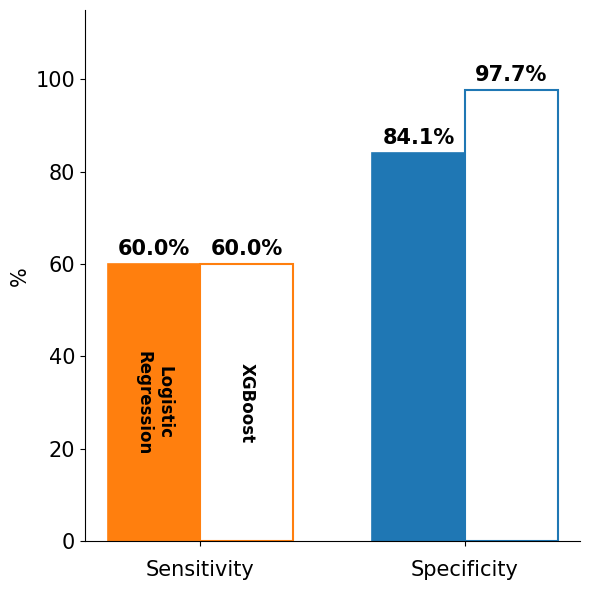

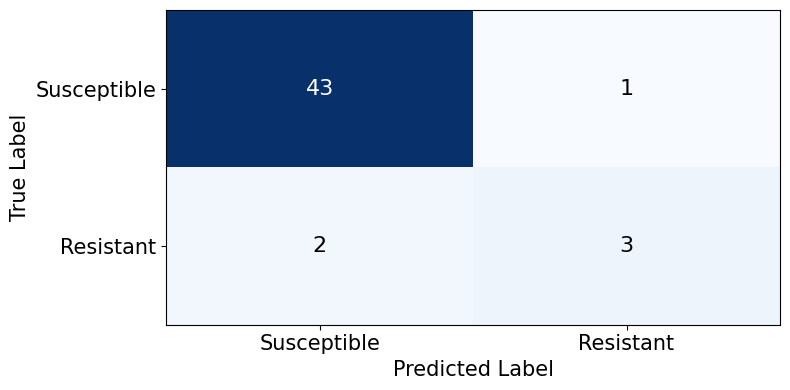

In [ ]:
# Detailed performance analysis
cnf_matrix_lr_s = metrics.confusion_matrix(y_test_s, y_pred_lr_s)
cnf_matrix_xgb_s = metrics.confusion_matrix(y_test_s, y_pred_xgb_s)

print("Singleton LR confusion matrix:")
print(cnf_matrix_lr_s)

print("\nSingleton XGB confusion matrix:")
print(cnf_matrix_xgb_s)

if cnf_matrix_lr_s.shape == (2, 2):
    tn, fp, fn, tp = cnf_matrix_lr_s.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"\nLR Sensitivity (resistance detection): {sensitivity:.3f}")
    print(f"LR Specificity (susceptible detection): {specificity:.3f}")

if cnf_matrix_xgb_s.shape == (2, 2):
    tn, fp, fn, tp = cnf_matrix_xgb_s.ravel()
    sensitivity_xgb_s = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_xgb_s = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"\nXGB Sensitivity (resistance detection): {sensitivity_xgb_s:.3f}")
    print(f"XGB Specificity (susceptible detection): {specificity_xgb_s:.3f}")

# Store LR singleton values for plotting
if cnf_matrix_lr_s.shape == (2, 2):
    tn, fp, fn, tp = cnf_matrix_lr_s.ravel()
    sensitivity_lr_s = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_lr_s = tn / (tn + fp) if (tn + fp) > 0 else 0

# Plot singleton sensitivity and specificity with enhanced styling
x_pos = np.arange(2)  # 0 = Sensitivity, 1 = Specificity
bar_width = 0.35

fig, ax = plt.subplots(figsize=(6, 6))

# Colors matching the reference plot styling
blue = '#1f77b4'    # Sensitivity
orange = '#ff7f0e'  # Specificity

# Bar values for both models (singleton)
lr_values_s = [sensitivity_lr_s, specificity_lr_s]  # Logistic Regression
xgb_values_s = [sensitivity_xgb_s, specificity_xgb_s]  # XGBoost

# Create bars with filled and hollow styling
bars_lr_s = ax.bar(x_pos - bar_width/2, lr_values_s, width=bar_width,
                   color=[orange, blue], edgecolor=[orange, blue], linewidth=1.2)

bars_xgb_s = ax.bar(x_pos + bar_width/2, xgb_values_s, width=bar_width,
                    color='white', edgecolor=[orange, blue], linewidth=1.5)

# Add percentage labels above bars
for bar, val in zip(list(bars_lr_s) + list(bars_xgb_s), lr_values_s + xgb_values_s):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val * 100:.1f}%', ha='center', va='bottom', fontsize=15, fontweight='bold')

# Add model labels inside bars (rotated)
model_labels_lr_s = ['Logistic\nRegression', '']
model_labels_xgb_s = ['XGBoost', '']

for i in range(2):  # 0 = sensitivity, 1 = specificity
    if model_labels_lr_s[i]:
        bar = bars_lr_s[i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                model_labels_lr_s[i], ha='center', va='center', rotation=270,
                fontsize=12, color='black', fontweight='bold')
    if model_labels_xgb_s[i]:
        bar = bars_xgb_s[i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                model_labels_xgb_s[i], ha='center', va='center', rotation=270,
                fontsize=12, color='black', fontweight='bold')

# Set labels and styling
ax.set_xticks(x_pos)
ax.set_xticklabels(['Sensitivity', 'Specificity'], fontsize=15)
ax.xaxis.set_tick_params(pad=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('%', fontsize=15)

# Format y-axis as percentages
yticks = ax.get_yticks()
ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)

# Clean styling - remove top and right spines
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', labelsize=15)

plt.tight_layout()
# plt.savefig('pdf/singleton_performance_sen_spec.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.show()

# Keep the confusion matrix visualization for singleton XGBoost
fig, ax2 = plt.subplots(figsize=(8, 4))
cm_s = cnf_matrix_xgb_s
im = ax2.imshow(cm_s, interpolation='nearest', cmap=plt.cm.Blues, aspect='auto')
# ax2.figure.colorbar(im, ax=ax2)

# Add text annotations
thresh = cm_s.max() / 2. if cm_s.max() > 0 else 0.5
for i in range(cm_s.shape[0]):
    for j in range(cm_s.shape[1]):
        ax2.text(j, i, format(cm_s[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_s[i, j] > thresh else "black", fontsize=16)

ax2.set_ylabel('True Label', fontsize=15)
ax2.set_xlabel('Predicted Label', fontsize=15)
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Susceptible', 'Resistant'], fontsize=15)
ax2.set_yticklabels(['Susceptible', 'Resistant'], fontsize=15)

# Force the aspect ratio to be rectangular (2:1)
ax2.set_aspect('auto')

plt.tight_layout()
plt.savefig('pdf/XGBoost_confusion_matrix_singleton_LEV.svg', format='svg', dpi=1200, bbox_inches='tight')
plt.show()

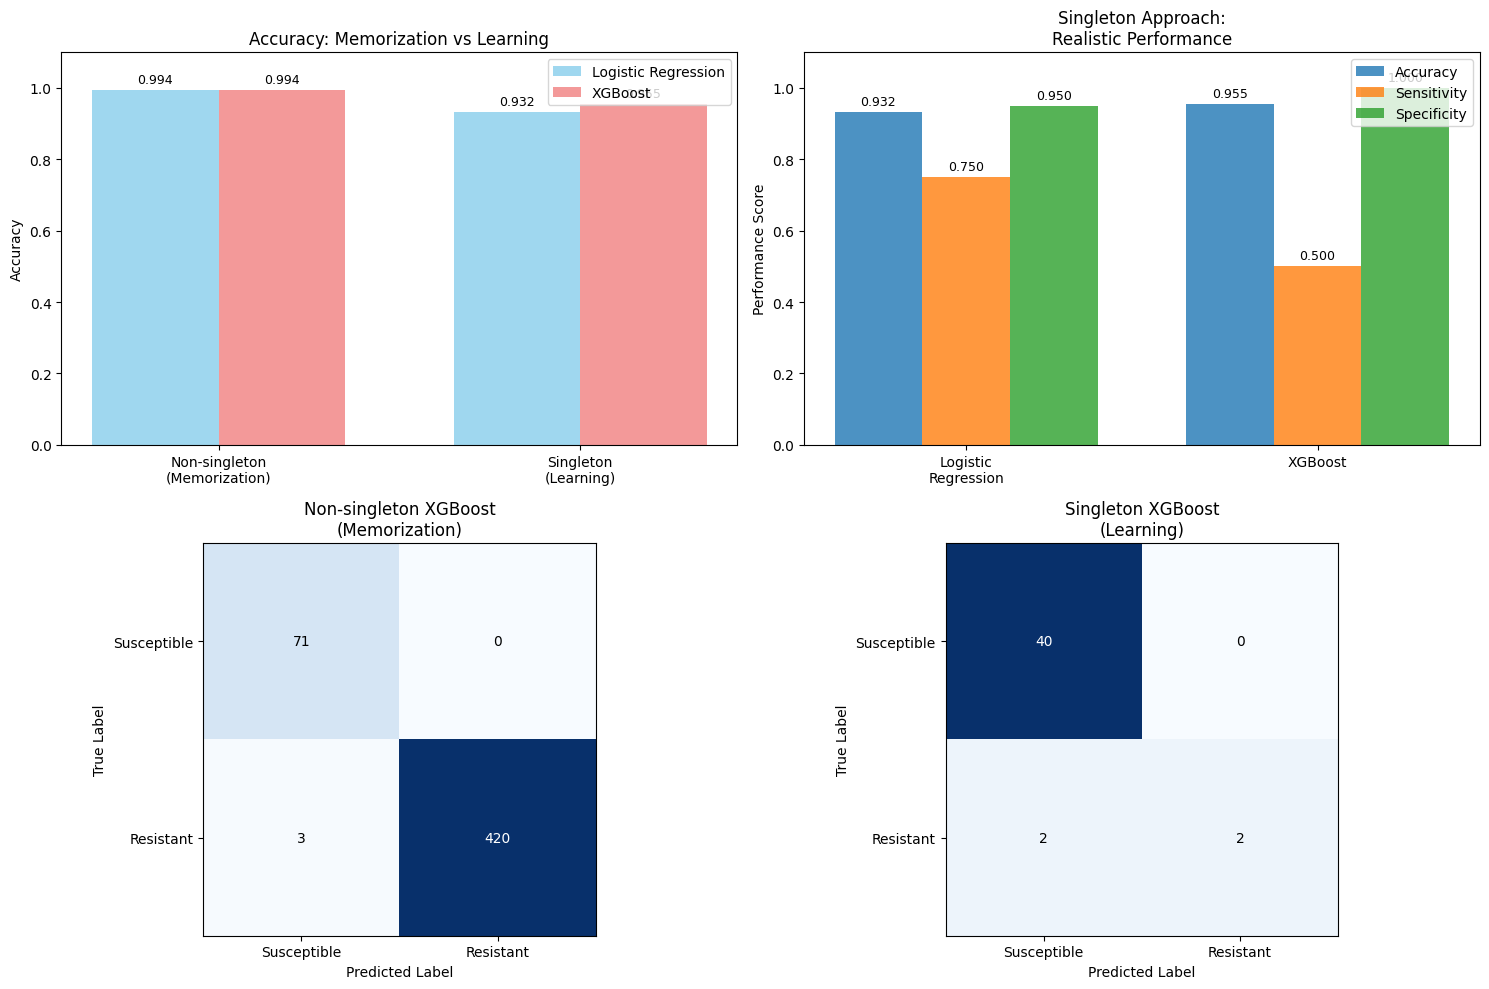

Performance degradation from memorization to learning:
XGBoost accuracy drop: 0.994 → 0.955
Sample size reduction: 1644 → 145 (8.8% retained)
This reveals the true difficulty of structure-based resistance prediction


In [44]:
# Visualize singleton approach performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Overall performance comparison between approaches
approaches = ['Non-singleton\n(Memorization)', 'Singleton\n(Learning)']
models = ['LR', 'XGB']

# Accuracy comparison
lr_acc_comp = [metrics.accuracy_score(y_test, y_pred_lr), metrics.accuracy_score(y_test_s, y_pred_lr_s)]
xgb_acc_comp = [metrics.accuracy_score(y_test, y_pred_xgb), metrics.accuracy_score(y_test_s, y_pred_xgb_s)]

x = np.arange(len(approaches))
width = 0.35

bars1 = ax1.bar(x - width/2, lr_acc_comp, width, label='Logistic Regression', alpha=0.8, color='skyblue')
bars2 = ax1.bar(x + width/2, xgb_acc_comp, width, label='XGBoost', alpha=0.8, color='lightcoral')

ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy: Memorization vs Learning')
ax1.set_xticks(x)
ax1.set_xticklabels(approaches)
ax1.legend()
ax1.set_ylim(0, 1.1)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Singleton approach detailed metrics
models_single = ['Logistic\nRegression', 'XGBoost']
singleton_acc = [metrics.accuracy_score(y_test_s, y_pred_lr_s), metrics.accuracy_score(y_test_s, y_pred_xgb_s)]

# Calculate singleton sensitivity and specificity
singleton_sens = []
singleton_spec = []

for cm in [cnf_matrix_lr_s, cnf_matrix_xgb_s]:
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        singleton_sens.append(sens)
        singleton_spec.append(spec)
    else:
        singleton_sens.append(0)
        singleton_spec.append(0)

x_single = np.arange(len(models_single))
width_single = 0.25

bars1 = ax2.bar(x_single - width_single, singleton_acc, width_single, label='Accuracy', alpha=0.8)
bars2 = ax2.bar(x_single, singleton_sens, width_single, label='Sensitivity', alpha=0.8)
bars3 = ax2.bar(x_single + width_single, singleton_spec, width_single, label='Specificity', alpha=0.8)

ax2.set_ylabel('Performance Score')
ax2.set_title('Singleton Approach:\nRealistic Performance')
ax2.set_xticks(x_single)
ax2.set_xticklabels(models_single)
ax2.legend()
ax2.set_ylim(0, 1.1)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Confusion matrices comparison
cms = [cnf_matrix_xgb, cnf_matrix_xgb_s]
titles = ['Non-singleton XGBoost\n(Memorization)', 'Singleton XGBoost\n(Learning)']
axes = [ax3, ax4]

for cm, title, ax in zip(cms, titles, axes):
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black")
    
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Susceptible', 'Resistant'])
    ax.set_yticklabels(['Susceptible', 'Resistant'])

plt.tight_layout()
plt.show()

print("Performance degradation from memorization to learning:")
print("====================================================")
print(f"XGBoost accuracy drop: {metrics.accuracy_score(y_test, y_pred_xgb):.3f} → {metrics.accuracy_score(y_test_s, y_pred_xgb_s):.3f}")
print(f"Sample size reduction: {len(data)} → {len(data_singleton)} ({len(data_singleton)/len(data):.1%} retained)")
print(f"This reveals the true difficulty of structure-based resistance prediction")

## Part 4: Comparison and conclusions

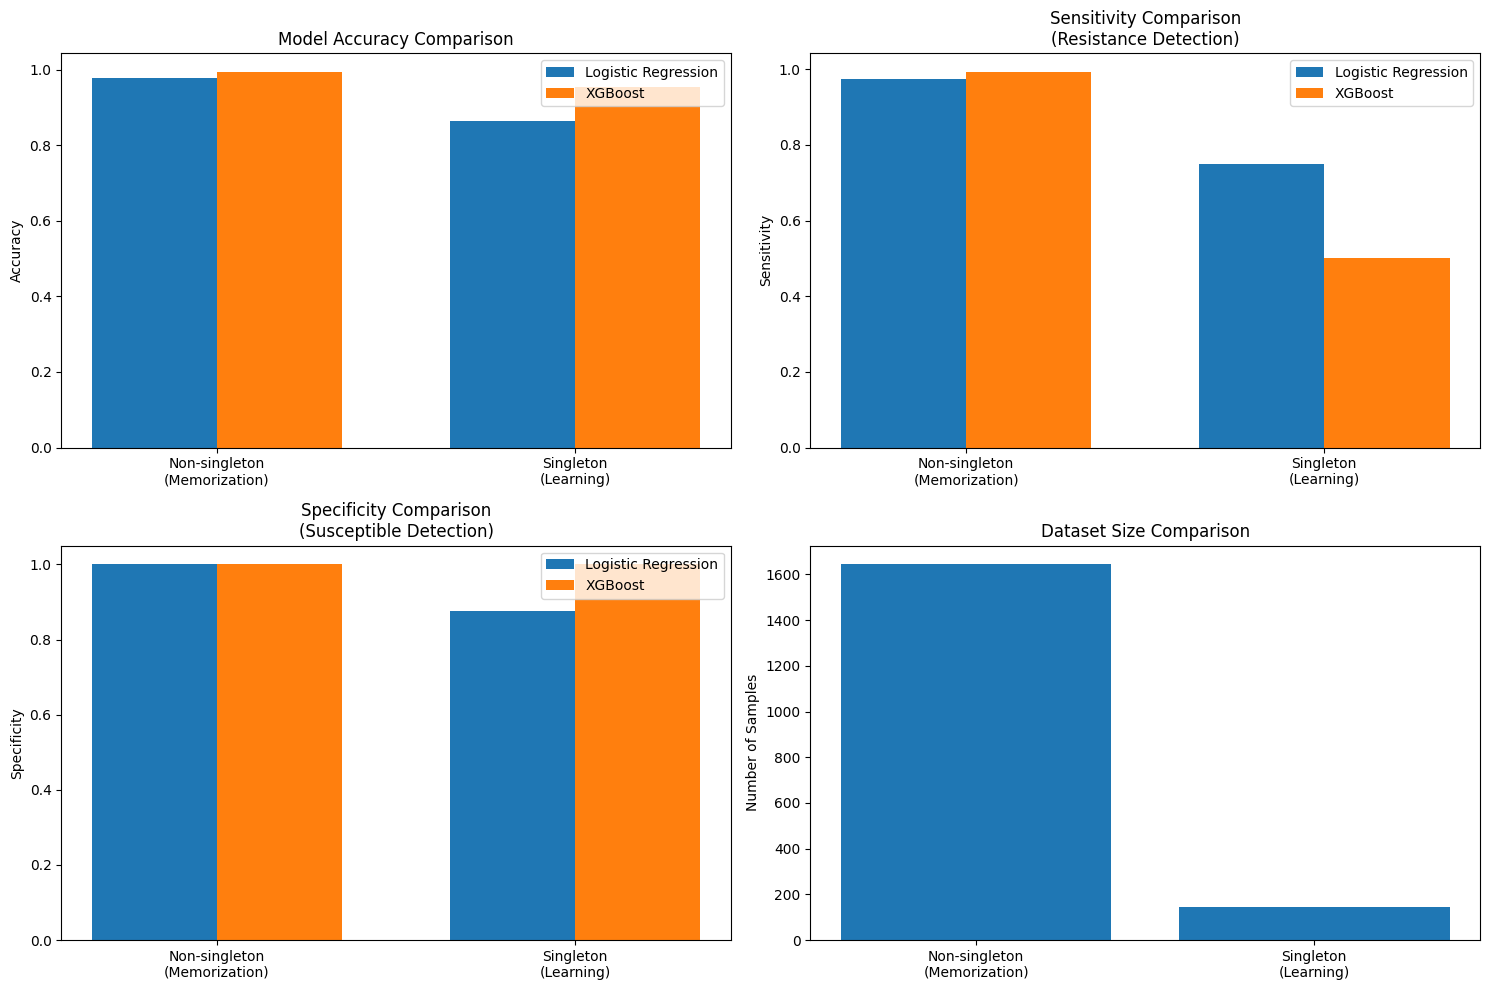

In [72]:
# Compare performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Performance comparison - Accuracy
approaches = ['Non-singleton\n(Memorization)', 'Singleton\n(Learning)']
lr_scores = [metrics.accuracy_score(y_test, y_pred_lr), metrics.accuracy_score(y_test_s, y_pred_lr_s)]
xgb_scores = [metrics.accuracy_score(y_test, y_pred_xgb), metrics.accuracy_score(y_test_s, y_pred_xgb_s)]

x = np.arange(len(approaches))
width = 0.35

ax1.bar(x - width/2, lr_scores, width, label='Logistic Regression')
ax1.bar(x + width/2, xgb_scores, width, label='XGBoost')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(approaches)
ax1.legend()

# Sensitivity comparison
lr_sens = [sensitivity_lr, cnf_matrix_lr_s.ravel()[3] / (cnf_matrix_lr_s.ravel()[3] + cnf_matrix_lr_s.ravel()[2]) if cnf_matrix_lr_s.shape == (2, 2) else 0]
xgb_sens = [sensitivity_xgb, cnf_matrix_xgb_s.ravel()[3] / (cnf_matrix_xgb_s.ravel()[3] + cnf_matrix_xgb_s.ravel()[2]) if cnf_matrix_xgb_s.shape == (2, 2) else 0]

ax2.bar(x - width/2, lr_sens, width, label='Logistic Regression')
ax2.bar(x + width/2, xgb_sens, width, label='XGBoost')
ax2.set_ylabel('Sensitivity')
ax2.set_title('Sensitivity Comparison\n(Resistance Detection)')
ax2.set_xticks(x)
ax2.set_xticklabels(approaches)
ax2.legend()

# Specificity comparison
lr_spec = [specificity_lr, cnf_matrix_lr_s.ravel()[0] / (cnf_matrix_lr_s.ravel()[0] + cnf_matrix_lr_s.ravel()[1]) if cnf_matrix_lr_s.shape == (2, 2) else 0]
xgb_spec = [specificity_xgb, cnf_matrix_xgb_s.ravel()[0] / (cnf_matrix_xgb_s.ravel()[0] + cnf_matrix_xgb_s.ravel()[1]) if cnf_matrix_xgb_s.shape == (2, 2) else 0]

ax3.bar(x - width/2, lr_spec, width, label='Logistic Regression')
ax3.bar(x + width/2, xgb_spec, width, label='XGBoost')
ax3.set_ylabel('Specificity')
ax3.set_title('Specificity Comparison\n(Susceptible Detection)')
ax3.set_xticks(x)
ax3.set_xticklabels(approaches)
ax3.legend()

# Sample size comparison
sample_sizes = [len(data), len(data_singleton)]
ax4.bar(approaches, sample_sizes)
ax4.set_ylabel('Number of Samples')
ax4.set_title('Dataset Size Comparison')

plt.tight_layout()
plt.show()

In [73]:
# Performance summary table
summary_data = {
    'Approach': ['Non-singleton (LR)', 'Non-singleton (XGB)', 'Singleton (LR)', 'Singleton (XGB)'],
    'Accuracy': [
        metrics.accuracy_score(y_test, y_pred_lr),
        metrics.accuracy_score(y_test, y_pred_xgb),
        metrics.accuracy_score(y_test_s, y_pred_lr_s),
        metrics.accuracy_score(y_test_s, y_pred_xgb_s)
    ],
    'Sensitivity': [
        sensitivity_lr,
        sensitivity_xgb,
        cnf_matrix_lr_s.ravel()[3] / (cnf_matrix_lr_s.ravel()[3] + cnf_matrix_lr_s.ravel()[2]) if cnf_matrix_lr_s.shape == (2, 2) else 0,
        cnf_matrix_xgb_s.ravel()[3] / (cnf_matrix_xgb_s.ravel()[3] + cnf_matrix_xgb_s.ravel()[2]) if cnf_matrix_xgb_s.shape == (2, 2) else 0
    ],
    'Specificity': [
        specificity_lr,
        specificity_xgb,
        cnf_matrix_lr_s.ravel()[0] / (cnf_matrix_lr_s.ravel()[0] + cnf_matrix_lr_s.ravel()[1]) if cnf_matrix_lr_s.shape == (2, 2) else 0,
        cnf_matrix_xgb_s.ravel()[0] / (cnf_matrix_xgb_s.ravel()[0] + cnf_matrix_xgb_s.ravel()[1]) if cnf_matrix_xgb_s.shape == (2, 2) else 0
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.round(3)

print("Performance Summary:")
print("==================")
print(summary_df.to_string(index=False))

print(f"\nKey observations:")
print(f"• Non-singleton approaches show artificially high performance across all metrics")
print(f"• Singleton approaches reveal more realistic (modest) performance")
print(f"• Large performance gap demonstrates memorization vs learning effect")

Performance Summary:
           Approach  Accuracy  Sensitivity  Specificity
 Non-singleton (LR)     0.978        0.974        1.000
Non-singleton (XGB)     0.994        0.993        1.000
     Singleton (LR)     0.864        0.750        0.875
    Singleton (XGB)     0.955        0.500        1.000

Key observations:
• Non-singleton approaches show artificially high performance across all metrics
• Singleton approaches reveal more realistic (modest) performance
• Large performance gap demonstrates memorization vs learning effect


In [74]:
# Final analysis
print("Key findings:")
print(f"1. Non-singleton approach: {len(overlapping_mutations)/len(test_mutations):.1%} data leakage")
print(f"2. Perfect mutation-phenotype consistency enables memorization")
print(f"3. High performance on 'novel' mutations due to gene-level patterns")
print(f"4. Singleton approach reveals true difficulty: only {singleton_counts['R']} resistant mutations")
print(f"5. Modest singleton performance reflects biological complexity")

print("\nConclusion:")
print("For FQ resistance in TB, we lack sufficient biological understanding")
print("and diverse resistance mutation data for reliable structure-based prediction.")
print("Non-singleton approaches create false optimism through memorization.")

Key findings:
1. Non-singleton approach: 56.9% data leakage
2. Perfect mutation-phenotype consistency enables memorization
3. High performance on 'novel' mutations due to gene-level patterns
4. Singleton approach reveals true difficulty: only 19 resistant mutations
5. Modest singleton performance reflects biological complexity

Conclusion:
For FQ resistance in TB, we lack sufficient biological understanding
and diverse resistance mutation data for reliable structure-based prediction.
Non-singleton approaches create false optimism through memorization.
